In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

state vector dim = 2
n_actions = 3


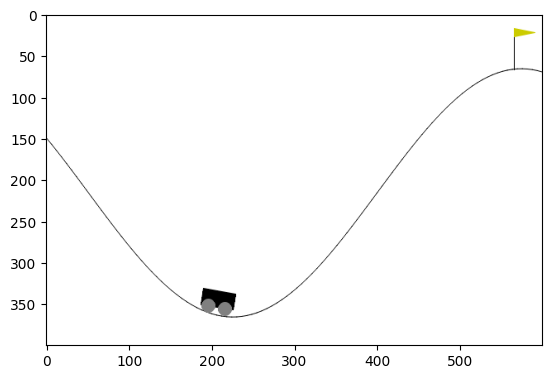

In [2]:
env_id = "MountainCar-v0"
env = gym.make(env_id, render_mode="rgb_array", max_episode_steps=10_000)

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

# env.close()

In [3]:
env

<TimeLimit<OrderEnforcing<PassiveEnvChecker<MountainCarEnv<MountainCar-v0>>>>>

In [4]:
from IPython import display
from IPython.display import clear_output

In [5]:
def render(env, agent, t_max: int = 1_000):
    s, _ = env.reset()
    clear_output(True)
    plt.imshow(env.render())

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:   
        probs = agent.predict_proba(s.reshape((1,-1))).reshape((n_actions,))

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(n_actions, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        plt.imshow(env.render())
        display.display(plt.gcf())
        display.clear_output(wait=True)

        # record sessions like you did before
        s = new_s
        if terminated or truncated:
            break

In [6]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(50, 50, 50, 25),
    activation="relu",
)

agent = agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), classes=list(range(n_actions)))

In [7]:
from copy import deepcopy

In [8]:
# render(env, agent, 100)

In [9]:
def generate_session(env_id: str | gym.Env, agent: MLPClassifier, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    if isinstance(env_id, str):
        env = gym.make(env_id, max_episode_steps=-1)
    else:
        env = env_id
    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:   
        probs = agent.predict_proba(s.reshape((1,-1))).reshape((n_actions,))

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(n_actions, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [10]:
dummy_states, dummy_actions, dummy_reward = generate_session(env_id, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[-0.42149544  0.        ]
 [-0.4232493  -0.00175386]
 [-0.42574447 -0.00249516]
 [-0.42796305 -0.00221857]
 [-0.4318891  -0.00392604]]
actions: [0, 1, 2, 0, 2]
reward: -5.0


In [11]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    # new_rewards = {val[0]: [] for val in states_batch}
    # ids = {val[0]: [] for val in states_batch}
    # for i, states in enumerate(states_batch):
    #     new_rewards[states[0]].append(rewards_batch[i])
    #     ids[states[0]].append(i)
    # mask = [0] * len(rewards_batch)

    # for st in new_rewards:
    #     reward_threshold = np.percentile(new_rewards[st], q=percentile)
    #     for i, r in enumerate(new_rewards[st]):
    #         if r >= reward_threshold:
    #             mask[ids[st][i]] = 1

    reward_threshold = np.percentile(rewards_batch, q=percentile)
    # for i, r in enumerate(rewards_batch):
    #     if r >= reward_threshold:
    #         mask[i] = 1

    elite_states = []
    elite_actions = []

    for i, r in enumerate(rewards_batch):
        if r > reward_threshold:
            elite_states.extend(states_batch[i])
            elite_actions.extend(actions_batch[i])

    return elite_states, elite_actions


In [ ]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.yscale('log')

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()
    # plt.close()


In [13]:
from joblib import Parallel, delayed

In [14]:
def gen_many_sessions(env_id, agent, t_max, cnt):
    return [generate_session(env_id, agent, t_max) for _ in range(cnt)]

In [15]:
def make_sessions(env_id, n_sessions: int, t_max: int):
    NUM_WORKERS = 20
    results = Parallel(n_jobs=NUM_WORKERS)(
        delayed(gen_many_sessions)(env_id, agent, t_max, n_sessions // NUM_WORKERS)
        for _ in range(NUM_WORKERS)
    )
    ans = []
    for el in results:
        ans.extend(el)
    return ans
    # return results


In [16]:
log = []
buffer = []

In [17]:
def train(n_sessions = 200, percentile = 90, cnt_epochs = 100):
    global buffer
    global log

    for i in range(cnt_epochs):
        # generate new sessions
        sessions = make_sessions(env_id, n_sessions, t_max=15_000)

        all_ses = []
        all_ses.extend(sessions)
        for el in buffer:
            all_ses.extend(el)

        states_batch, actions_batch, rewards_batch = zip(*all_ses)
        # print(sessions)
        # print(states_batch)
        # print(actions_batch)
        # print(rewards_batch)

        elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

        # print(elite_actions)
        # print(elite_states)
        if elite_states:
            agent.partial_fit(elite_states, elite_actions)
        # <YOUR CODE: partial_fit agent to predict elite_actions(y) from elite_states(X)>

        abs_rewards = np.abs(rewards_batch)
        show_progress(
            abs_rewards, log, 100 - percentile, reward_range=[np.min(abs_rewards), np.max(abs_rewards)]
        )

        if np.mean(rewards_batch) > 190:
            print("You Win! You may stop training now via KeyboardInterrupt.")
        buffer.append(sessions)
        buffer = buffer[-5:]
        # print(len(buffer))
        # print(len(sessions))
        # print(len(all_ses))
        # input()

mean reward = 4748.235, threshold=1142.800


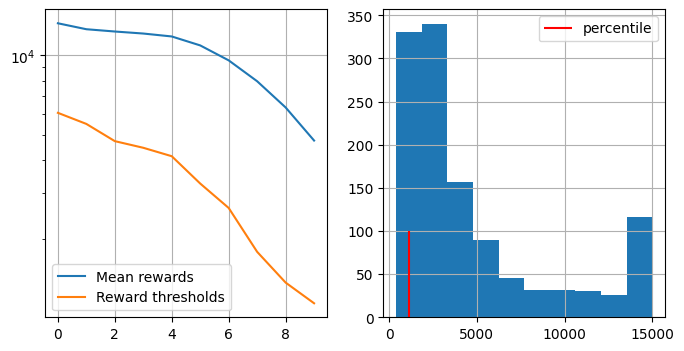

In [18]:
train(200, 90, 10)

mean reward = 106.996, threshold=96.800


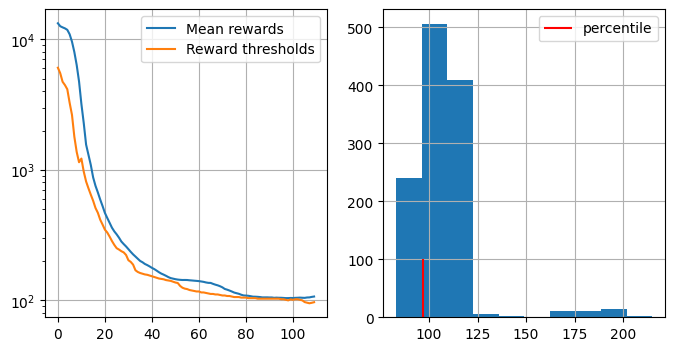

In [19]:
train(200, 80, 100)

mean reward = 100.123, threshold=103.000


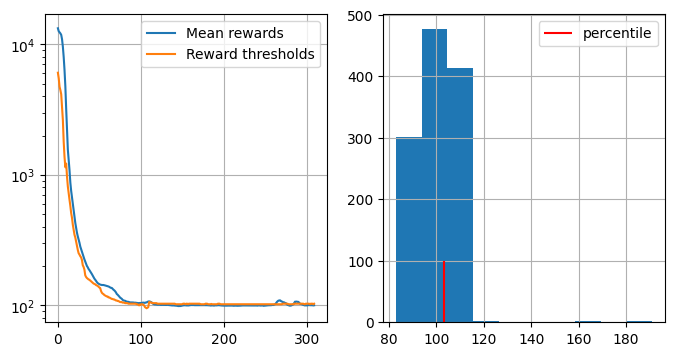

In [20]:
train(200, 60, 200)

mean reward = 98.837, threshold=103.000


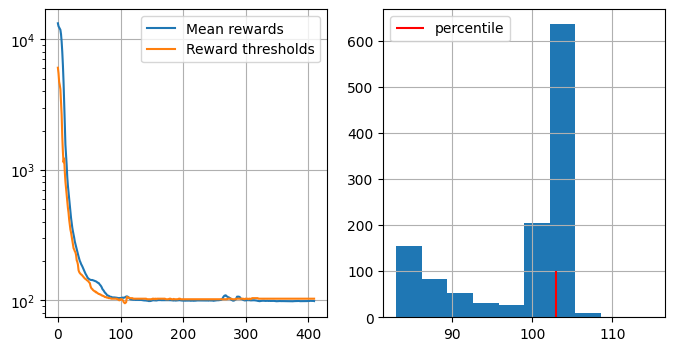

In [21]:
train(200, 45, 100)

In [22]:
# n_sessions = 200
# percentile = 90
# log = []
# buffer = []

# for i in range(100):
#     # generate new sessions
#     sessions = make_sessions(env_id, n_sessions, t_max=15_000)

#     all_ses = []
#     all_ses.extend(sessions)
#     for el in buffer:
#         all_ses.extend(el)

#     states_batch, actions_batch, rewards_batch = zip(*all_ses)
#     # print(sessions)
#     # print(states_batch)
#     # print(actions_batch)
#     # print(rewards_batch)

#     elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

#     # print(elite_actions)
#     # print(elite_states)
#     if elite_states:
#         agent.partial_fit(elite_states, elite_actions)
#     # <YOUR CODE: partial_fit agent to predict elite_actions(y) from elite_states(X)>

#     abs_rewards = np.abs(rewards_batch)
#     show_progress(
#         abs_rewards, log, 100 - percentile, reward_range=[np.min(abs_rewards), np.max(abs_rewards)]
#     )

#     if np.mean(rewards_batch) > 190:
#         print("You Win! You may stop training now via KeyboardInterrupt.")
#     buffer.append(sessions)
#     buffer = buffer[-5:]
#     # print(len(buffer))
#     # print(len(sessions))
#     # print(len(all_ses))
#     # input()


In [23]:
from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make(env_id, render_mode="rgb_array"),
    video_folder=f"./{env_id}_videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent, t_max=500) for _ in range(5)]

c:\Users\sapeg\OneDrive\Desktop\SAD_Yandex\RL\Practical_RL\rl-venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\sapeg\OneDrive\Desktop\SAD_Yandex\RL\Practical_RL\week01_intro\MountainCar-v0_videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [27]:
def save_agent(agent, path):
    from pickle import dump
    with open(path, 'wb') as f:
        dump(agent, f)

save_agent(agent, 'mountain_car_agent.pkl')

In [25]:
def load_agent(path):
    from pickle import load
    with open(path, 'rb') as f:
        return load(f)

In [28]:
model = load_agent('mountain_car_agent.pkl')

In [36]:
states_batch, actions_batch, rewards_batch = zip(*[generate_session(env, model, t_max=250) for _ in range(100)])
print(np.mean(rewards_batch))

-98.77
